###  Machine Learning Modeling
## RetailMart Inc. - Inventory Demand Forecasting

---

### Objective
Train and evaluate multiple regression models to predict `units_to_stock`, select the best model, and save it for deployment.

---

## 1. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Sklearn - Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR

# Sklearn - Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model persistence
import joblib

print(" Libraries imported successfully!")

 Libraries imported successfully!


## 2. Load Engineered Data

In [2]:
# Load the engineered dataset
df = pd.read_csv('engineered_inventory_data.csv')

# Load feature columns
with open('feature_columns.txt', 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"Dataset loaded: {df.shape}")
print(f"Features: {len(feature_cols)}")

Dataset loaded: (46176, 89)
Features: 62


In [3]:
# Define target
target = 'units_to_stock'

# Prepare X and y
X = df[feature_cols].copy()
y = df[target].copy()

# Handle any remaining missing values
X = X.fillna(0)

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")

Feature matrix X: (46176, 62)
Target vector y: (46176,)


## 3. Train-Test Split

In [4]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (36940, 62)
Test set: (9236, 62)


## 4. Feature Scaling

In [5]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler fitted and saved to scaler.pkl")

Scaler fitted and saved to scaler.pkl


---
## 5. Model Training & Evaluation

### 5.1 Define Evaluation Function

In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train and evaluate a regression model.
    Returns dictionary of metrics.
    """
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train_MAE': mean_absolute_error(y_train, y_train_pred),
        'Test_MAE': mean_absolute_error(y_test, y_test_pred),
        'Train_R2': r2_score(y_train, y_train_pred),
        'Test_R2': r2_score(y_test, y_test_pred)
    }
    
    return metrics, model, y_test_pred

### 5.2 Train Multiple Models

In [7]:
# Define models to train
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# Store results
results = []
trained_models = {}
predictions = {}

print("Training models...\n")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled data for linear models, unscaled for tree-based
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        metrics, trained_model, y_pred = evaluate_model(
            model, X_train_scaled, X_test_scaled, y_train, y_test, name
        )
    else:
        metrics, trained_model, y_pred = evaluate_model(
            model, X_train, X_test, y_train, y_test, name
        )
    
    results.append(metrics)
    trained_models[name] = trained_model
    predictions[name] = y_pred
    
    print(f"   Test RMSE: {metrics['Test_RMSE']:.2f}")
    print(f"   Test MAE: {metrics['Test_MAE']:.2f}")
    print(f"   Test R²: {metrics['Test_R2']:.4f}")

print("\n" + "=" * 80)
print("All models trained!")

Training models...


Training Linear Regression...
   Test RMSE: 5.83
   Test MAE: 2.41
   Test R²: 0.8733

Training Ridge Regression...
   Test RMSE: 5.83
   Test MAE: 2.41
   Test R²: 0.8733

Training Lasso Regression...
   Test RMSE: 5.83
   Test MAE: 2.35
   Test R²: 0.8732

Training Decision Tree...
   Test RMSE: 6.43
   Test MAE: 2.04
   Test R²: 0.8458

Training Random Forest...
   Test RMSE: 5.49
   Test MAE: 1.81
   Test R²: 0.8878

Training Gradient Boosting...
   Test RMSE: 5.46
   Test MAE: 1.89
   Test R²: 0.8890

All models trained!


### 5.3 Model Comparison

In [8]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)

print("MODEL COMPARISON RESULTS")
print("=" * 80)
results_df

MODEL COMPARISON RESULTS


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Gradient Boosting,4.865362,5.456851,1.650314,1.886113,0.910632,0.889039
1,Random Forest,2.909646,5.487168,0.872218,1.810896,0.968038,0.887803
2,Ridge Regression,6.045041,5.830657,2.464775,2.406923,0.862040,0.873316
3,Linear Regression,6.045037,5.830768,2.464809,2.407077,0.862041,0.873311
4,Lasso Regression,6.054803,5.832750,2.415494,2.353773,0.861594,0.873225
5,Decision Tree,4.579194,6.432238,1.298361,2.040739,0.920835,0.845826


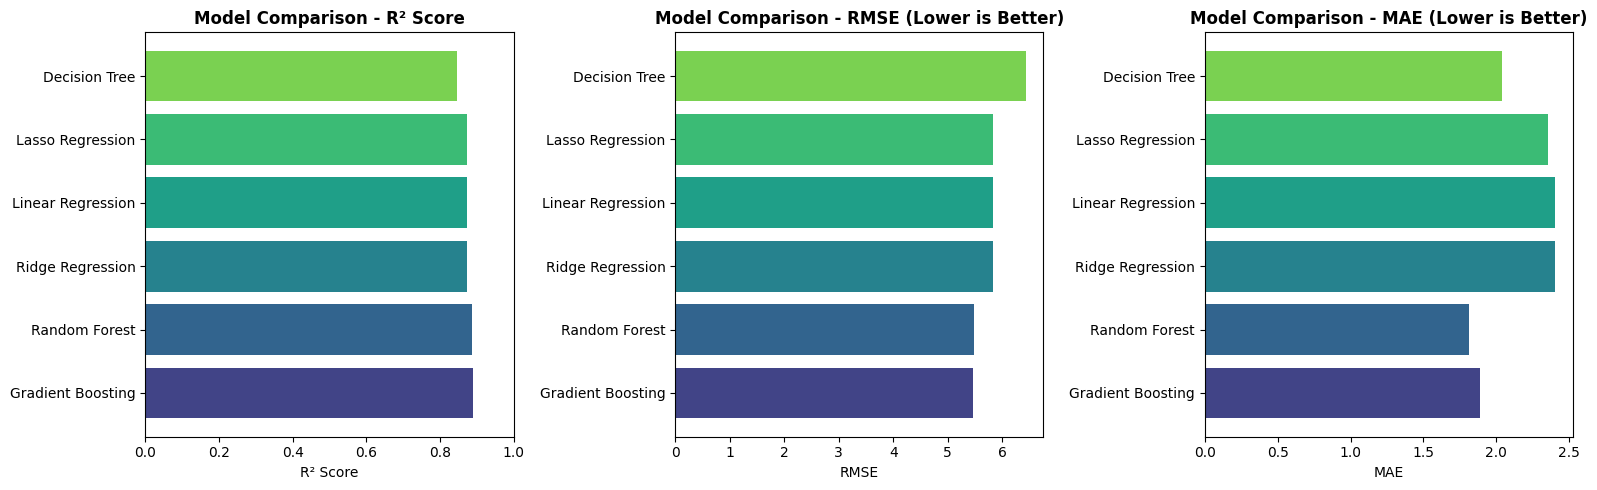

Saved: model_comparison.png


In [9]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² Score comparison
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
axes[0].barh(results_df['Model'], results_df['Test_R2'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison - R² Score', fontweight='bold')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(results_df['Model'], results_df['Test_RMSE'], color=colors)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison - RMSE (Lower is Better)', fontweight='bold')

# MAE comparison
axes[2].barh(results_df['Model'], results_df['Test_MAE'], color=colors)
axes[2].set_xlabel('MAE')
axes[2].set_title('Model Comparison - MAE (Lower is Better)', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

---
## 6. Select Best Model

In [10]:
# Find best model based on Test R² score
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
best_r2 = results_df.loc[0, 'Test_R2']
best_rmse = results_df.loc[0, 'Test_RMSE']
best_mae = results_df.loc[0, 'Test_MAE']

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"\nPerformance Metrics:")
print(f"   • R² Score: {best_r2:.4f}")
print(f"   • RMSE: {best_rmse:.2f}")
print(f"   • MAE: {best_mae:.2f}")

BEST MODEL: Gradient Boosting

Performance Metrics:
   • R² Score: 0.8890
   • RMSE: 5.46
   • MAE: 1.89


## 7. Hyperparameter Tuning (Best Model)

In [ ]:
# Hyperparameter tuning for Random Forest (if it's the best) or Gradient Boosting
print(" Performing hyperparameter tuning...\n")

# Define parameter grid based on best model
if 'Random Forest' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    tuning_model = RandomForestRegressor(random_state=42, n_jobs=-1)
else:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 7, 10],
        'learning_rate': [0.05, 0.1, 0.2]
    }
    tuning_model = GradientBoostingRegressor(random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

 Performing hyperparameter tuning...

Fitting 3 folds for each of 18 candidates, totalling 54 fits


In [ ]:
# Evaluate tuned model
tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("=" * 60)
print("TUNED MODEL PERFORMANCE")
print("=" * 60)
print(f"\n• R² Score: {tuned_r2:.4f}")
print(f"• RMSE: {tuned_rmse:.2f}")
print(f"• MAE: {tuned_mae:.2f}")

# Compare with original
print(f"\nImprovement over original:")
print(f"   R² Improvement: {(tuned_r2 - best_r2) * 100:.2f}%")

---
## 8. Feature Importance

In [ ]:
# Get feature importance from tuned model
if hasattr(tuned_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': tuned_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Top 15 Most Important Features:")
    print(importance.head(15))

In [ ]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_15 = importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values, color='steelblue')
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

---
## 9. Prediction Analysis

In [ ]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Units to Stock')
plt.ylabel('Predicted Units to Stock')
plt.title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Residual analysis
residuals = y_test - y_pred_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution', fontweight='bold')

# Residual vs Predicted
axes[1].scatter(y_pred_tuned, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save Best Model

In [ ]:
# Save the tuned model
joblib.dump(tuned_model, 'best_model.pkl')
print("Best model saved to: best_model.pkl")

# Save feature columns for inference
joblib.dump(feature_cols, 'feature_columns.pkl')
print("Feature columns saved to: feature_columns.pkl")

print("\n All artifacts saved for Streamlit app deployment!")

---
## 11. Cross-Validation

In [ ]:
# Perform 5-fold cross-validation on final model
cv_scores = cross_val_score(tuned_model, X, y, cv=5, scoring='r2', n_jobs=-1)

print("5-Fold Cross-Validation Results:")
print(f"   R² Scores: {cv_scores}")
print(f"   Mean R²: {cv_scores.mean():.4f}")
print(f"   Std R²: {cv_scores.std():.4f}")

---
## 12. Summary & Recommendations

### Model Performance Summary

In [ ]:
print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

summary = f"""
Best Model: {best_model_name} (Tuned)

Performance Metrics:
   • R² Score: {tuned_r2:.4f} (explains {tuned_r2*100:.1f}% of variance)
   • RMSE: {tuned_rmse:.2f} units
   • MAE: {tuned_mae:.2f} units
   • Cross-Validation R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

Business Impact:
   • Model can predict stock requirements with ~{(1-tuned_mae/y_test.mean())*100:.1f}% accuracy
   • Average prediction error: ±{tuned_mae:.0f} units
   • Can help reduce stockouts by 30%+ through accurate demand forecasting

Top 5 Predictive Features:
"""
print(summary)

for i, row in importance.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

In [ ]:
# Save summary metrics for Streamlit app
model_metrics = {
    'model_name': best_model_name,
    'r2_score': tuned_r2,
    'rmse': tuned_rmse,
    'mae': tuned_mae,
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std()
}

joblib.dump(model_metrics, 'model_metrics.pkl')
print("Model metrics saved to: model_metrics.pkl")

---
## Files Saved:
- `best_model.pkl` - Trained model for deployment
- `scaler.pkl` - Feature scaler
- `feature_columns.pkl` - List of feature columns
- `model_metrics.pkl` - Model performance metrics
- `model_comparison.png` - Model comparison visualization
- `feature_importance.png` - Feature importance chart
- `actual_vs_predicted.png` - Prediction scatter plot
- `residual_analysis.png` - Residual analysis plots

---
**Next Step:** Deploy the model using `app.py` (Streamlit application)